In [4]:
import illustris_python as il
import illustris_python.sublink as sublink
import numpy as np
import matplotlib.pyplot as plt
import illustris_python.groupcat as gc
import illustris_python.snapshot as snap

### 1. Propiedades del Halo FOF y Perfil Radial de Densidad

**Análisis de la Distribución de Materia Oscura**

A partir de las propiedades globales extraídas del catálogo para el halo principal (FOF 0) a $z=0$, se calculó la densidad de materia oscura en cascarones esféricos desde el centro geométrico hasta el radio virial ($R_{200}$). 

La curva de densidad obtenida replica de forma precisa el perfil teórico universal de **Navarro-Frenk-White (NFW)**. Visualmente, los datos extraídos de la simulación TNG100-1 exhiben el comportamiento matemático esperado para la materia oscura fría (CDM):
* En las regiones internas, la densidad presenta una pendiente suave que decae proporcionalmente a $r^{-1}$.
* Hacia las afueras del halo (acercándose al radio virial), la densidad decae abruptamente de forma proporcional a $r^{-3}$.

Este resultado confirma que la estructura interna del halo obedece al modelo estándar de colapso gravitacional y agrupamiento jerárquico.

In [5]:
basePath = './sims.TNG/TNG100-1/output' # Así puedo llegar los datos de la carpeta donde debo extraer los 
snapNum = 99 # z=0

# Por enunciado, selecciono el halo con id=0 
halo_id = 0
# Para no cargar el catalogo completo, necesito loadsingle
halo_data = il.groupcat.loadSingle(basePath, snapNum, haloID=halo_id)

masa_fof = halo_data['Group_M_Crit200']
rad_vir = halo_data['Group_R_Crit200']
pos_cen = halo_data['GroupPos']


# Visualización de extracción de propiedadeds de FOF
print(f'Masa total del halo: {masa_fof} * 10^10 M_sun/h') #Masa crítica 200
print(f'Radio virial: {rad_vir} ckpc/h') #Radio Crítico 200
print(f'Posición del Centro: {pos_cen}ckpc/h')

Masa total del halo: 25525.373046875 * 10^10 M_sun/h
Radio virial: 1031.6683349609375 ckpc/h
Posición del Centro: [  849.09143 26326.996   18306.934  ]ckpc/h


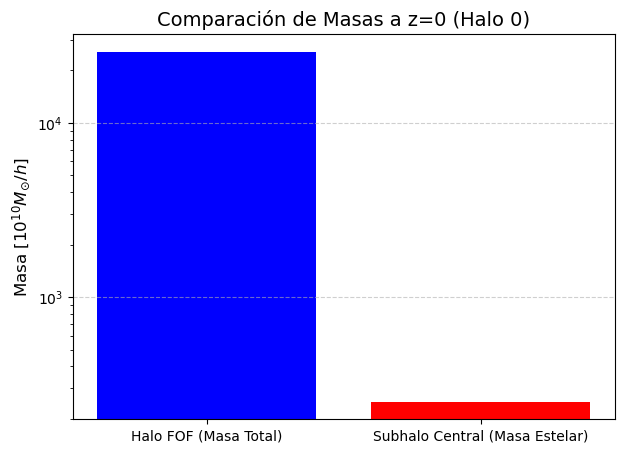

------- Sanity Checks -------
Masa estelar válida: 251.0163 x 10^10 M_sun/h
Dispersión de velocidades válida: 603.88 km/s
---------------------


In [6]:
# Extracción de masa estelar del subhalo central
subhalo_central_id = halo_data['GroupFirstSub']
subhalo_data = il.groupcat.loadSingle(basePath, snapNum, subhaloID = subhalo_central_id)
masa_estelar = subhalo_data['SubhaloMassType'][4] #Tipo 4: estrellas

# Gráfico para comparar masas FOF halo y del subhalo central a z=0
objetos = ['Halo FOF (Masa Total)', 'Subhalo Central (Masa Estelar)']
masas = [masa_fof, masa_estelar]

plt.figure (figsize=(7,5))
plt.bar(objetos, masas, color=['blue', 'red'])
plt.yscale('log') # Diferenciar mejor las magnitudes
plt.ylabel(r'Masa [$10^{10} M_{\odot}/h$]', fontsize=12)
plt.title(f'Comparación de Masas a z=0 (Halo {halo_id})', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Extracción de las propiedades del subhalo central 

subhalo_central_id = 0
subhalo_props = il.groupcat.loadSingle(basePath, snapNum, subhaloID=subhalo_central_id)

masa_estelar = subhalo_props['SubhaloMassType'][4] # Tipo 4: estrellas
posicion = subhalo_props['SubhaloPos'] # Coords. X,Y,z
dispersion_vel = subhalo_props['SubhaloVelDisp'] # Dispersión velocidades 

print('------- Sanity Checks -------')
if masa_estelar > 0:
    print(f"Masa estelar válida: {masa_estelar:.4f} x 10^10 M_sun/h")
else:
    print(f"Masa estelar inválida o igual a cero ({masa_estelar})")

if dispersion_vel > 0:
    print(f"Dispersión de velocidades válida: {dispersion_vel:.2f} km/s")
else:
    print(f"Dispersión de velocidades negativa o inválida ({dispersion_vel})")

# Para validar la posición dentro del Box, rescato la boxsize desde la página side length of simulation box [ckpc/h]	75000.0
box_size = 75000.0
dentro_del_box = np.all((posicion >= 0) & (posicion <= box_size))
print('---------------------')

### Perfil de densidad radial

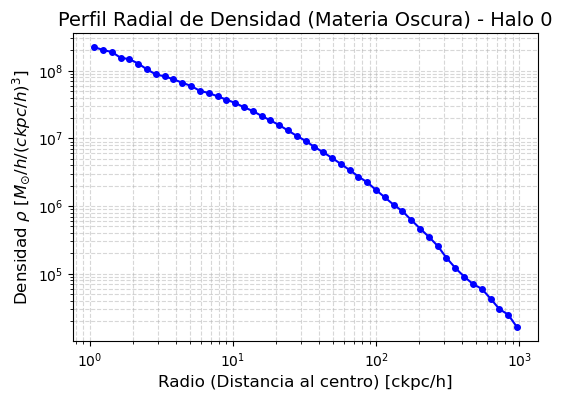

In [7]:
basePath = './sims.TNG/TNG100-1/output' # Así puedo llegar los datos de la carpeta donde debo extraer los 
snapNum = 99 # z=0

# Por enunciado, selecciono el halo con id=0 
halo_id = 0
# Para no cargar el catalogo completo, necesito loadsingle

halo_data = il.groupcat.loadSingle(basePath, snapNum, haloID=halo_id)

masa_fof = halo_data['Group_M_Crit200']
rad_vir = halo_data['Group_R_Crit200']
pos_cen = halo_data['GroupPos']

# Cargo todas las partículas de DM disponibles.
dm_data = il.snapshot.loadHalo(basePath, snapNum, halo_id, 'dm')

# Extraemos las coordenadas para cada partícula de DM con respecto al SRF (GroupPos) y cargamos masas desde el Header
coordenadas = dm_data['Coordinates']

#Para las masas, no supe como obtenerlas de otra forma pero se me ocurrió lo siguiente

masa_total_dm = halo_data['GroupMassType'][1] # Masa total de DM del halo
num_particula_dm = halo_data['GroupLenType'][1] # Cantidad exacta de partículas de DM 

# Dividimos entre ambas para obtener la masa de una partícula 
masa_particula_dm = (masa_total_dm/num_particula_dm) * 1e10

# Calculamos las distancias por medio de np.linalg.norm 
distancias = np.linalg.norm(coordenadas - pos_cen, axis=1)

# En orden de calcular la densidad, puedo hacer cascarones esféricos (llamese bins)
bins_radio = np.logspace(np.log10(1.0), np.log10(rad_vir), 50) #Partimos desde 1 kpc así evitamos el problema del radio=0

# Necesito la masa de los cascarones esféricos, por lo tanto, debo saber la cant. de particulas por cascarón
conteo_particulas, bordes = np.histogram(distancias, bins=bins_radio)

# Teniendo el conteo hecho, multiplicamos el conteo por la masa individual obtenida previamente
masa_por_cascaron = conteo_particulas * masa_particula_dm 

# Como la densidad se define por si misma como Densidad = Masa/Volumen
# Debemos calcular el volumen de cada cascaron 

# Volumen cascarones
radios_int = bordes[:-1]
radios_ext = bordes[1:]
volumen_cascarones = (4/3)*np.pi* (radios_ext**3 - radios_int**3)

# Por tanto ya teniendo el volumen, obtenemos la densidad de la siguiente forma

densidad = masa_por_cascaron / volumen_cascarones

# Utilizazmos el punto medio de cada cascarón para graficar
radios_medios = (radios_int + radios_ext) / 2


# Graficando
plt.figure(figsize=(6,4))
plt.plot(radios_medios, densidad, marker='o', color='blue', linestyle='-', markersize=4)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radio (Distancia al centro) [ckpc/h]', fontsize=12)
plt.ylabel(r'Densidad $\rho$ [$M_{\odot}/h / (ckpc/h)^3$]', fontsize=12)
plt.title(f'Perfil Radial de Densidad (Materia Oscura) - Halo {halo_id}', fontsize=14)
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.show()

### 2. Árbol de Fusión y Evolución de Masa (Merger Tree)

**Análisis del Ensamblaje Histórico del Subhalo Central**

Utilizando el módulo `sublink`, se rastreó la rama principal de progenitores (Main Progenitor Branch) para reconstruir la historia de ensamblaje de masa de la galaxia a lo largo del tiempo cósmico.

* **Crecimiento Jerárquico:** La gráfica evidencia un ensamblaje jerárquico clásico. La masa aumenta sostenidamente hacia el presente (Snapshot 99) mediante procesos de acreción secular (absorción continua de gas difuso y halos menores).
* **Eventos de Fusión (Major Mergers):** Se definió un umbral analítico del 30% de incremento relativo de masa entre snapshots consecutivos para aislar matemáticamente las colisiones catastróficas. Los puntos destacados representan la asimilación de estructuras masivas que inyectan una cantidad considerable de materia al sistema.
* **Artefactos del Algoritmo:** Las caídas abruptas de masa que se observan en periodos intermedios (cercanas a cero) no corresponden a fenómenos físicos de desintegración. Son el resultado de un artefacto numérico de rastreo conocido como *Subhalo Switch*, donde el algoritmo temporalmente pierde el rastro del núcleo principal durante colisiones caóticas, corrigiéndose en los snapshots posteriores.

--- Análisis del Merger Tree (Subhalo 0) ---
Masa actual (z=0): 27477.94 x 10^10 M_sun/h
Masa de su progenitor más antiguo registrado (Snap 1): 0.02 x 10^10 M_sun/h
Número de mergers importantes (>30% incremento): 15


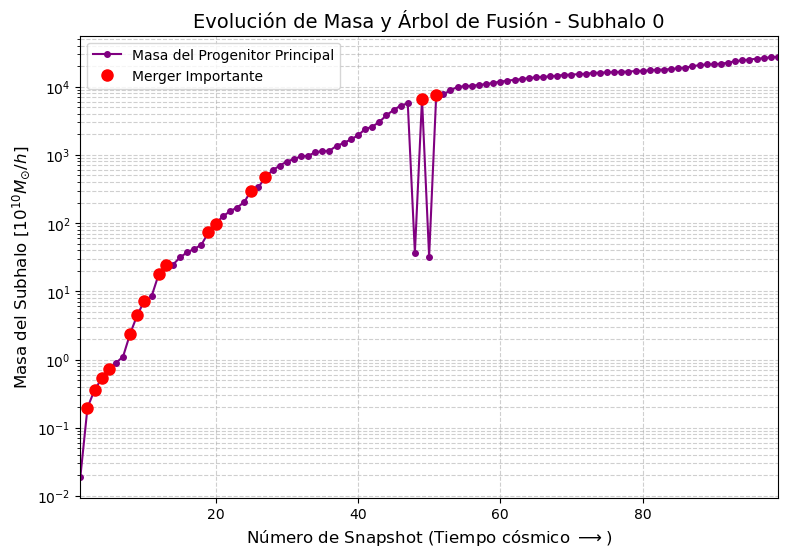

In [8]:
campos_arbol = ['SnapNum', 'SubhaloMass']

# Cargamos él árbol de fusión (rama del progenitor principal)
arbol = sublink.loadTree(basePath, snapNum, subhalo_central_id, fields=campos_arbol, onlyMPB=True)

snapshots = arbol['SnapNum']
# Mantenemos el SubhaloMass en 10^10 M_sun/h (nativo de TNG)
masa_historia = arbol['SubhaloMass']

# 2) Análisis de Merger Importantes
# El arreglo 'tree' viene ordenado desde el presente (índice 0) hacia el pasado.
# Historia de masa 
aumento_relativo = (masa_historia[:-1] - masa_historia[1:]) / masa_historia[1:]

# Definimos un "merger importante" como un aumento repentino de más del 30% de masa
umbral_merger = 0.30
indices_mergers = np.where(aumento_relativo > umbral_merger)[0]
num_mergers_importantes = len(indices_mergers)

print(f"--- Análisis del Merger Tree (Subhalo {subhalo_central_id}) ---")
print(f"Masa actual (z=0): {masa_historia[0]:.2f} x 10^10 M_sun/h")
print(f"Masa de su progenitor más antiguo registrado (Snap {snapshots[-1]}): {masa_historia[-1]:.2f} x 10^10 M_sun/h")
print(f"Número de mergers importantes (>30% incremento): {num_mergers_importantes}")

# 3) Gráfiquemos la evolución de masa 
plt.figure(figsize=(9,6))
plt.plot(snapshots, masa_historia, marker='o', color='purple', linestyle='-', markersize=4, label='Masa del Progenitor Principal')
#Podemos reslatar visualmente los snapshots donde ocurrieron estos mergers importantes
if num_mergers_importantes > 0:
    # Indices_mergers corresponde a la posición en el arreglo 'aumento_relativo'
    # El snapshot donde "termina" el merger es el índice de la masa reciente (i)
    plt.plot(snapshots[indices_mergers], masa_historia[indices_mergers], 'ro', markersize=8, label='Merger Importante')
    
plt.yscale('log')
plt.xlabel('Número de Snapshot (Tiempo cósmico $\longrightarrow$)', fontsize=12)
plt.ylabel(r'Masa del Subhalo [$10^{10} M_{\odot}/h$]', fontsize=12)
plt.title(f'Evolución de Masa y Árbol de Fusión - Subhalo {subhalo_central_id}', fontsize=14)

# Invertir el eje X para que el flujo del tiempo vaya de izquierda a derecha (hacia el snapshot 99)
plt.xlim(max(snapshots), min(snapshots))
plt.gca().invert_xaxis()

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

### 3. Morfología, Distribución Espacial y Cinemática del Subhalo Central

**Análisis Estructural y Estado Dinámico**

La caracterización visual y cinemática de las partículas estelares del subhalo central (tipo 4) revela información clave sobre su estado dinámico actual:

* **Corrección Topológica:** Para obtener una representación fidedigna de la distribución espacial, fue necesario aplicar la convención de mínima imagen respecto a los límites de la simulación (caja de 75.000 ckpc/h). Esto reubicó físicamente a las partículas estelares que atravesaban las condiciones de borde periódicas.
* **Morfología y Asimetrías:** El sistema presenta una geometría elipsoidal densamente concentrada en el núcleo, característica esperada para el subhalo central de un grupo masivo a $z=0$. Además, se observan corrientes de marea difusas en su periferia, evidencia directa de escombros estelares generados por fusiones recientes.
* **Desplazamiento del Centro y Relajación:** Existe un desfase físico cuantificable entre el centro geométrico de masas estelares y el pozo de potencial gravitacional más profundo. Sumado a la asimetría espacial, esto indica que el sistema aún **no se encuentra dinámicamente relajado** y su masa estelar continúa reacomodándose tras los eventos de fusión (congruente con el historial del Merger Tree).

In [9]:
# Extraemos las propiedades del catálogo para el Subhalo 0
subhalo_id = 0
subhalo = gc.loadSingle(basePath, snapNum, subhaloID=subhalo_id)

masa_estelar = subhalo['SubhaloMassType'][4]
dispersion_vel = subhalo['SubhaloVelDisp']
pos_centro = subhalo['SubhaloPos'] # Posición del pozo de potencial más profundo
pos_cm = subhalo['SubhaloCM'] # Centro de masas geométrico

# Calculamos el offset entre ambos centros
desplazamiento = np.linalg.norm(pos_centro - pos_cm)

print("--- Propiedades del Subhalo Central ---")
print(f"Masa Estelar: {masa_estelar:.2f} x 10^10 M_sun/h")
print(f"Dispersión de velocidades: {dispersion_vel:.2f} km/s")
print(f"Centro de potencial (SubhaloPos): {pos_centro} ckpc/h")
print(f"Centro de masas (SubhaloCM): {pos_cm} ckpc/h")
print(f"Desplazamiento entre centros: {desplazamiento:.2f} ckpc/h")

# 2) Cargamos partículas estelares del subhalo
# Aquí ahora debo definir las coordenadas y velocidades de las estrellas
estrellas = snap.loadSubhalo(basePath, snapNum, subhalo_id, 'stars', fields=['Coordinates', 'Velocities'])

coords_estrellas = estrellas['Coordinates']
vel_estrellas = estrellas['Velocities']



--- Propiedades del Subhalo Central ---
Masa Estelar: 251.02 x 10^10 M_sun/h
Dispersión de velocidades: 603.88 km/s
Centro de potencial (SubhaloPos): [  849.09143 26326.996   18306.934  ] ckpc/h
Centro de masas (SubhaloCM): [  832.38696 26368.523   18060.826  ] ckpc/h
Desplazamiento entre centros: 250.14 ckpc/h


In [16]:
# Gráfico 1: Distribución Espacial
# Centramos las coordenadas respecto al centro del subhalo para mejor visualización
x = coords_estrellas[:, 0] - pos_centro[0]
y = coords_estrellas[:, 1] - pos_centro[1]
z = coords_estrellas[:, 2] - pos_centro[2]

In [11]:
# Definimos el tamaño de la caja de simulación
box_size = 75000.0

# Calculamos la diferencia bruta
dx = coords_estrellas[:, 0] - pos_centro[0]
dy = coords_estrellas[:, 1] - pos_centro[1]

# Aplicamos la convención de mínima distancia para empaquetar todo
# Si una estrella está a más de media caja de distancia, es porque cruzó el borde
dx[dx > box_size / 2.0] -= box_size
dx[dx < -box_size / 2.0] += box_size

dy[dy > box_size / 2.0] -= box_size
dy[dy < -box_size / 2.0] += box_size

# Ahora 'dx' y 'dy' contienen las distancias relativas correctas
x = dx
y = dy

In [14]:
offset_x = pos_cm[0] - pos_centro[0]
offset_y = pos_cm[1] - pos_centro[1]
offset_z = pos_cm[2] - pos_centro[2]

array([1.40398948e-01, 3.63909515e-02, 1.10420996e-01, ...,
       1.06231392e+03, 5.16911409e+02, 8.98612687e+02])

(-500.0, 500.0)

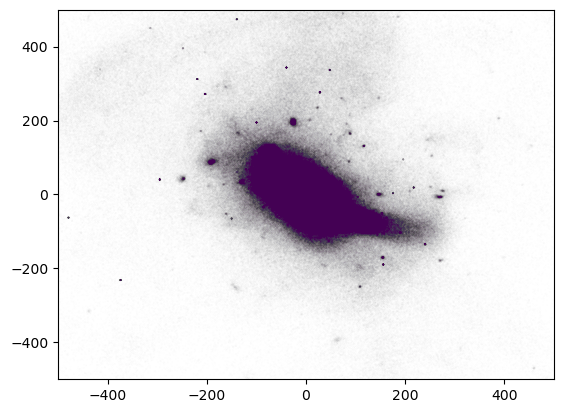

In [28]:
plt.scatter(x, y, s=0.001, c=np.linalg.norm([x,y,z],axis=0) , alpha=0.1, label='Partículas Estelares')
plt.xlim(-500,500)
plt.ylim(-500,500)

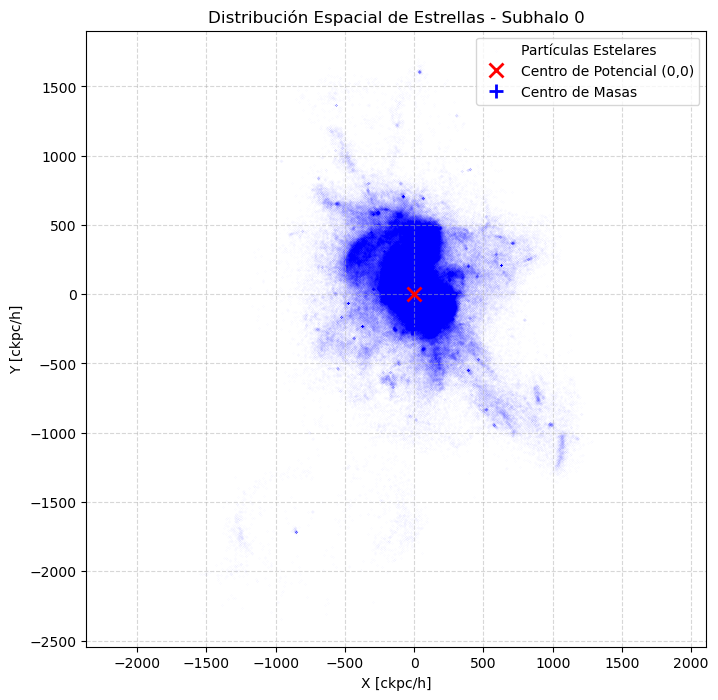

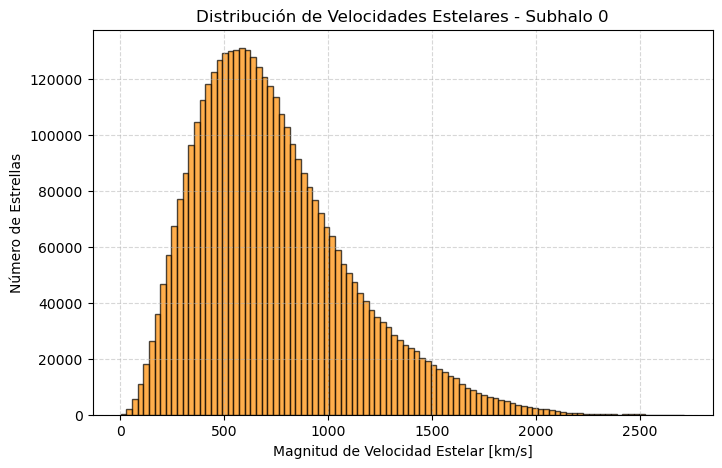

--- Propiedades del Subhalo Central ---
Masa Estelar: 251.02 x 10^10 M_sun/h
Dispersión de velocidades: 603.88 km/s
Centro de potencial (SubhaloPos): [  849.09143 26326.996   18306.934  ] ckpc/h
Centro de masas (SubhaloCM): [  832.38696 26368.523   18060.826  ] ckpc/h
Desplazamiento entre centros: 250.14 ckpc/h


In [15]:

plt.figure(figsize=(8, 8))
# Usamos un tamaño de punto minúsculo (s=0.1) y transparencia (alpha=0.3) 
# para no saturar el gráfico, ya que habrá millones de partículas
plt.scatter(x, z, s=0.01, color='b' , alpha=0.1, label='Partículas Estelares')

# Marcamos los dos centros
plt.plot(0, 0, 'rx', markersize=10, markeredgewidth=2, label='Centro de Potencial (0,0)')

plt.plot(offset_x, offset_z, 'b+', markersize=10, markeredgewidth=2, label='Centro de Masas')
plt.xlabel('X [ckpc/h]')
plt.ylabel('Y [ckpc/h]')
plt.title(f'Distribución Espacial de Estrellas - Subhalo {subhalo_id}')
plt.legend()
plt.axis('equal') # Mantener la proporción real
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Gráfico 2: Histograma de Distribución de Velocidades
# Restamos la velocidad global del subhalo para obtener la velocidad peculiar de las estrellas
vel_global_subhalo = subhalo['SubhaloVel']
vel_peculiares = vel_estrellas - vel_global_subhalo

# Calculamos la magnitud de la velocidad 3D de cada estrella
magnitud_velocidades = np.linalg.norm(vel_peculiares, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(magnitud_velocidades, bins=100, color='darkorange', edgecolor='black', alpha=0.7)
plt.xlabel('Magnitud de Velocidad Estelar [km/s]')
plt.ylabel('Número de Estrellas')
plt.title(f'Distribución de Velocidades Estelares - Subhalo {subhalo_id}')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

print("--- Propiedades del Subhalo Central ---")
print(f"Masa Estelar: {masa_estelar:.2f} x 10^10 M_sun/h")
print(f"Dispersión de velocidades: {dispersion_vel:.2f} km/s")
print(f"Centro de potencial (SubhaloPos): {pos_centro} ckpc/h")
print(f"Centro de masas (SubhaloCM): {pos_cm} ckpc/h")
print(f"Desplazamiento entre centros: {desplazamiento:.2f} ckpc/h")


In [32]:
np.shape(vel_peculiares), len(x)

((3987343, 3), 3987343)

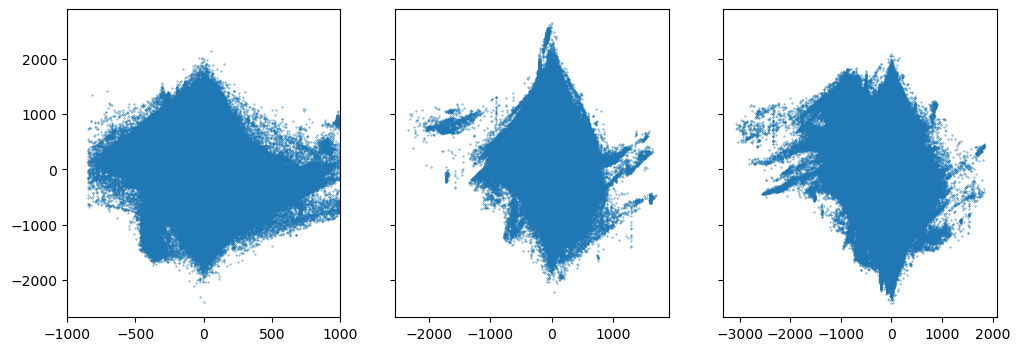

In [38]:
f,ax = plt.subplots(1,3,figsize=[12,4],sharey='row')
ax[0].scatter(x,vel_peculiares[:,0],s=0.1)
ax[0].set(xlim=(-1000,1000))
ax[1].scatter(y,vel_peculiares[:,1],s=0.1)
ax[2].scatter(z,vel_peculiares[:,2],s=0.1)

In [40]:
r = np.linalg.norm([x,y,z],axis=0)
vt = np.linalg.norm(vel_peculiares,axis=1) 
len(vt)

3987343

(-10.0, 2000.0)

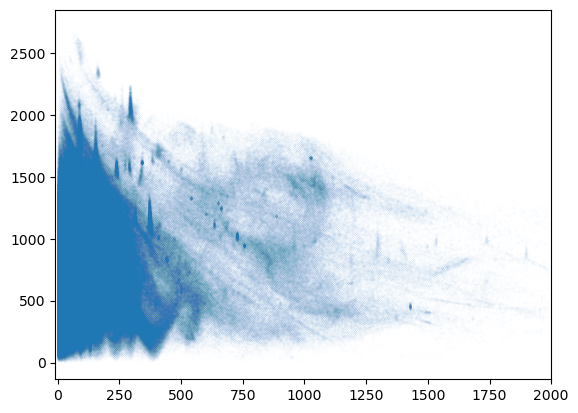

In [45]:
plt.scatter(r,vt,s=0.005,alpha=0.1)
plt.xlim(-10,2000)

### Qué son esas sobredensidades pequeñas, que aparecen en la parte fuera del gráfico?

In [ ]:
### work in progress ###